# 15 Figure 4 Resistance-Controlled Performance Regimes

Purpose:
This notebook prepares draft plots and exported data for Figure 4.

Figure 4A:
- Relationship between internal resistance and hydrovoltaic performance
- log(R) vs log(P_est)
- scatter plot with binned mean trend

Figure 4B:
- Performance distribution by resistance regime
- low-R vs high-R devices

Figure 4C:
- Interpretable resistance-regime rule schematic

Figure 4D:
- Physics-aware R descriptor comparison
- raw log(R), centered log(R), and R-regime descriptor

The plots generated here are draft plots for inspection. Final panels will be redrawn in Igor Pro or Illustrator.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

out_dir = Path("../results/figure4_resistance_regimes")
out_dir.mkdir(parents=True, exist_ok=True)

print("Output folder:", out_dir.resolve())

# Draft plot style
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.linewidth"] = 1.0

Output folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure4_resistance_regimes


In [2]:
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000",
    "gray": "#666666",
    "light_gray": "#DDDDDD",
    "very_light_gray": "#F2F2F2"
}

In [3]:
# Candidate dataset files
candidate_files = [
    "hydrovoltaic_dataset_phase2_input_utf8.csv",
    "hydrovoltaic_clean_phase1.csv",
    "hydrovoltaic_clean.csv",
    "../notebooks/hydrovoltaic_dataset_phase2_input_utf8.csv",
    "../notebooks/hydrovoltaic_clean_phase1.csv",
    "../notebooks/hydrovoltaic_clean.csv",
]

data_path = None

for f in candidate_files:
    p = Path(f)
    if p.exists():
        data_path = p
        break

if data_path is None:
    print("No candidate dataset file was found.")
    print("CSV files in current folder:")
    for f in Path(".").glob("*.csv"):
        print(" -", f.name)
    raise FileNotFoundError("Please update candidate_files with the correct dataset filename.")

df = pd.read_csv(data_path, encoding="utf-8-sig")

print("Loaded:", data_path)
print("Dataset shape:", df.shape)
display(df.head())

Loaded: hydrovoltaic_dataset_phase2_input_utf8.csv
Dataset shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,auxiliary_redox_present,continuous_output,water_interaction_mode,rh_percent,inorganic_electrolyte_present,inorganic_electrolyte_type,inorganic_electrolyte_concentration_wt%,polyelectrolyte_present,active_material_raw,material_class,structure_class,ionic_groups,top_electrode,bottom_electrode,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_Mohm,output_timescale_class,stability_time_min,dominant_mechanism,has_anionic,has_cationic,has_zwitterionic,polyelectrolyte_anionic_raw,polyelectrolyte_cationic_raw,polyelectrolyte_zwitterionic_raw,has_any_polyelectrolyte,estimated_power_density_uW_cm2,log_estimated_power_density,ion_type,asym_env,asym_chem,asym_electrode,mechanism_simple,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,60.0,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,0,0,0,NaN,NaN,NaN,0,0.003750,-2.425853,proton,1,0,0,streaming,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,0,1,evaporation_driven,62.0,0,NaN,NaN,0,ZnO,metal oxide,porous,hydroxyl,Al,Al,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,0,0,0,NaN,NaN,NaN,0,0.002000,-2.698753,anion,1,0,0,streaming,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,lanthanum iron perovskite oxide,semiconductor,porous,hydroxyl,CNT,CNT,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,0,0,0,NaN,NaN,NaN,0,0.009375,-2.027982,anion,1,1,0,streaming,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,0,0,0,NaN,NaN,NaN,0,0.007820,-2.106738,proton,1,0,0,streaming,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,55.0,0,NaN,NaN,0,carbonized rice husk,carbon,porous,"carboxyl, hydroxyl, silanol",CNT,CNT,1,0.0,0.16,0.0400,NaN,NaN,hours,600.0,streaming,0,0,0,NaN,NaN,NaN,0,0.001600,-2.795609,proton,1,0,0,streaming,1,0,0,NaN,0


In [4]:
def find_first_existing_column(df, candidates):
    """
    Return the first column name in candidates that exists in df.
    """
    for c in candidates:
        if c in df.columns:
            return c
    return None


def find_column_by_keywords(df, must_include):
    """
    Return the first column whose lowercase name contains all keywords.
    """
    must_include = [k.lower() for k in must_include]
    for c in df.columns:
        c_low = c.lower()
        if all(k in c_low for k in must_include):
            return c
    return None

In [5]:
# Target column candidates
target_log_candidates = [
    "log_estimated_power_density",
    "log_P_est",
    "log_Pest",
    "log_estimated_power_density_uW_cm2",
]

target_raw_candidates = [
    "estimated_power_density_uW_cm2",
    "P_est",
    "Pest",
    "estimated_power_density",
]

# Resistance column candidates
R_log_candidates = [
    "log_internal_resistance_Mohm",
    "log_internal_resistance_MΩ",
    "log_R",
    "logR",
]

R_raw_candidates = [
    "internal_resistance_Mohm",
    "internal_resistance_MΩ",
    "internal_resistance",
    "R_Mohm",
]

target_log_col = find_first_existing_column(df, target_log_candidates)
target_raw_col = find_first_existing_column(df, target_raw_candidates)

R_log_col = find_first_existing_column(df, R_log_candidates)
R_raw_col = find_first_existing_column(df, R_raw_candidates)

# Fallback fuzzy search
if target_log_col is None:
    target_log_col = find_column_by_keywords(df, ["log", "power"])

if target_raw_col is None:
    target_raw_col = find_column_by_keywords(df, ["power"])

if R_log_col is None:
    R_log_col = find_column_by_keywords(df, ["log", "resistance"])

if R_raw_col is None:
    R_raw_col = find_column_by_keywords(df, ["resistance"])

print("Detected columns:")
print("target_log_col:", target_log_col)
print("target_raw_col:", target_raw_col)
print("R_log_col:", R_log_col)
print("R_raw_col:", R_raw_col)

Detected columns:
target_log_col: log_estimated_power_density
target_raw_col: estimated_power_density_uW_cm2
R_log_col: log_internal_resistance_Mohm
R_raw_col: internal_resistance_Mohm


In [6]:
fig4_df = df.copy()

# Build log(P_est)
if target_log_col is not None:
    fig4_df["log_P_est"] = pd.to_numeric(fig4_df[target_log_col], errors="coerce")
elif target_raw_col is not None:
    raw_target = pd.to_numeric(fig4_df[target_raw_col], errors="coerce")
    fig4_df["log_P_est"] = np.log10(raw_target.where(raw_target > 0))
else:
    raise ValueError("No target column was found. Please check target column names.")

# Build log(R)
if R_log_col is not None:
    fig4_df["log_R"] = pd.to_numeric(fig4_df[R_log_col], errors="coerce")
elif R_raw_col is not None:
    raw_R = pd.to_numeric(fig4_df[R_raw_col], errors="coerce")
    fig4_df["log_R"] = np.log10(raw_R.where(raw_R > 0))
else:
    raise ValueError("No internal resistance column was found. Please check resistance column names.")

# Keep rows with both target and R
fig4_df = fig4_df.dropna(subset=["log_R", "log_P_est"]).copy()

print("Figure 4 dataset shape:", fig4_df.shape)
display(fig4_df[["log_R", "log_P_est"]].head())

print("log_R summary:")
display(fig4_df["log_R"].describe())

print("log_P_est summary:")
display(fig4_df["log_P_est"].describe())

Figure 4 dataset shape: (112, 54)


,log_R,log_P_est
0,0.903090,-2.425853
1,1.535294,-2.698753
2,1.778151,-2.027982
5,0.301030,-2.505011
11,0.301030,-1.332071


log_R summary:


count    112.000000
mean      -0.671009
std        1.363584
min       -3.468521
25%       -1.704539
50%       -0.903438
75%        0.182418
max        3.000000
Name: log_R, dtype: float64

log_P_est summary:


count    112.000000
mean      -0.229551
std        1.276323
min       -4.283997
25%       -1.108987
50%        0.018816
75%        0.650614
max        2.552060
Name: log_P_est, dtype: float64

## Fig. 4A — Relationship between R and performance

In [7]:
# Create binned trend data
# Number of bins for binned trend
N_BINS = 5

fig4A_df = fig4_df[["log_R", "log_P_est"]].copy()

# Quantile bins are more stable for heterogeneous literature data
fig4A_df["R_bin"] = pd.qcut(
    fig4A_df["log_R"],
    q=N_BINS,
    duplicates="drop"
)

fig4A_bin_df = (
    fig4A_df
    .groupby("R_bin", observed=False)
    .agg(
        log_R_center=("log_R", "mean"),
        log_R_min=("log_R", "min"),
        log_R_max=("log_R", "max"),
        mean_log_P_est=("log_P_est", "mean"),
        median_log_P_est=("log_P_est", "median"),
        std_log_P_est=("log_P_est", "std"),
        n=("log_P_est", "count")
    )
    .reset_index()
)

fig4A_bin_df["sem_log_P_est"] = fig4A_bin_df["std_log_P_est"] / np.sqrt(fig4A_bin_df["n"])

display(fig4A_bin_df)

,R_bin,log_R_center,log_R_min,log_R_max,mean_log_P_est,median_log_P_est,std_log_P_est,n,sem_log_P_est
0,"(-3.4699999999999998, -2.0]",-2.373854,-3.468521,-2.000000,0.629443,0.507164,0.922205,26,0.180859
1,"(-2.0, -1.114]",-1.451633,-1.769551,-1.124939,0.314807,0.449093,0.858356,19,0.196920
2,"(-1.114, -0.127]",-0.749207,-1.096910,-0.130182,-0.192319,-0.210120,1.131616,22,0.241261
3,"(-0.127, 0.318]",0.068274,-0.124939,0.301030,-0.946584,-1.114303,1.058471,22,0.225667
4,"(0.318, 3.0]",1.266469,0.322219,3.000000,-1.000033,-0.948844,1.447038,23,0.301728


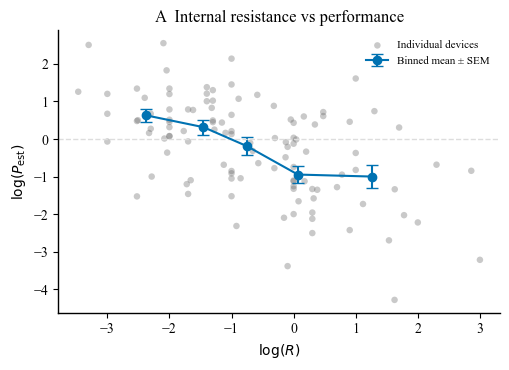

In [8]:
# Fig. 4A draft plot
fig, ax = plt.subplots(figsize=(5.2, 3.8))

# Scatter
ax.scatter(
    fig4A_df["log_R"],
    fig4A_df["log_P_est"],
    s=22,
    alpha=0.35,
    color=COLORS["gray"],
    edgecolor="none",
    label="Individual devices"
)

# Binned mean trend
ax.errorbar(
    fig4A_bin_df["log_R_center"],
    fig4A_bin_df["mean_log_P_est"],
    yerr=fig4A_bin_df["sem_log_P_est"],
    fmt="o-",
    markersize=6,
    linewidth=1.5,
    capsize=4,
    color=COLORS["blue"],
    ecolor=COLORS["blue"],
    label="Binned mean ± SEM"
)

ax.set_xlabel(r"$\log(R)$")
ax.set_ylabel(r"$\log(P_\mathrm{est})$")
ax.set_title("A  Internal resistance vs performance")

ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])

ax.legend(frameon=False, fontsize=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Fig. 4B — Performance by R regime

In [9]:
# Physics-aware threshold
# log_R = 0 corresponds to R = 1 MOhm if R is in MOhm.
R_THRESHOLD = -1.0

fig4_df["R_regime"] = np.where(
    fig4_df["log_R"] <= R_THRESHOLD,
    "low_R",
    "high_R"
)

fig4B_df = fig4_df[["log_R", "log_P_est", "R_regime"]].copy()

regime_order = ["low_R", "high_R"]

fig4B_summary_df = (
    fig4B_df
    .groupby("R_regime")
    .agg(
        count=("log_P_est", "count"),
        mean_log_P_est=("log_P_est", "mean"),
        median_log_P_est=("log_P_est", "median"),
        std_log_P_est=("log_P_est", "std"),
        mean_log_R=("log_R", "mean"),
        median_log_R=("log_R", "median")
    )
    .reindex(regime_order)
    .reset_index()
)

display(fig4B_summary_df)

,R_regime,count,mean_log_P_est,median_log_P_est,std_log_P_est,mean_log_R,median_log_R
0,low_R,55,0.413553,0.454845,0.957220,-1.807239,-1.721246
1,high_R,57,-0.850091,-0.823906,1.243873,0.425354,0.176091


C:\Users\wenlu\AppData\Local\Temp\ipykernel_4456\3683521160.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


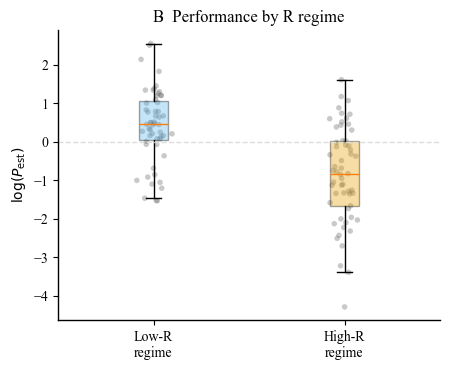

In [10]:
# Fig. 4B draft plot
fig, ax = plt.subplots(figsize=(4.6, 3.8))

data_by_regime = [
    fig4B_df.loc[fig4B_df["R_regime"] == reg, "log_P_est"].values
    for reg in regime_order
]

box = ax.boxplot(
    data_by_regime,
    labels=["Low-R\nregime", "High-R\nregime"],
    patch_artist=True,
    showfliers=False
)

# Box colors
for patch, color in zip(box["boxes"], [COLORS["sky"], COLORS["orange"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

# Overlay jittered points
rng = np.random.default_rng(42)
for i, reg in enumerate(regime_order, start=1):
    y = fig4B_df.loc[fig4B_df["R_regime"] == reg, "log_P_est"].values
    x = rng.normal(loc=i, scale=0.045, size=len(y))
    ax.scatter(
        x,
        y,
        s=16,
        alpha=0.35,
        color=COLORS["gray"],
        edgecolor="none"
    )

ax.set_ylabel(r"$\log(P_\mathrm{est})$")
ax.set_title("B  Performance by R regime")
ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Fig. 4C — Resistance-regime rule schematic

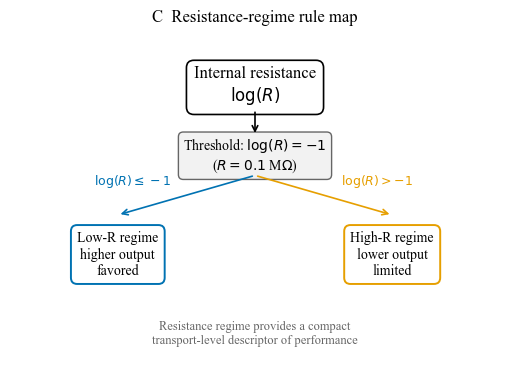

In [11]:
# Fig. 4C schematic

R_THRESHOLD = -1.0
R_THRESHOLD_TEXT = r"Threshold: $\log(R)=-1$" + "\n" + r"($R=0.1$ M$\Omega$)"

fig, ax = plt.subplots(figsize=(5.2, 3.8))

ax.axis("off")

# Coordinates
x_center = 0.50
x_left = 0.22
x_right = 0.78

# Main node
ax.text(
    x_center,
    0.83,
    r"Internal resistance" + "\n" + r"$\log(R)$",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.45", fc="white", ec=COLORS["black"], lw=1.2)
)

# Threshold node
ax.text(
    x_center,
    0.62,
    R_THRESHOLD_TEXT,
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", fc=COLORS["very_light_gray"], ec=COLORS["gray"], lw=1.0)
)

# Low-R node
ax.text(
    x_left,
    0.32,
    "Low-R regime\nhigher output\nfavored",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.45", fc="white", ec=COLORS["blue"], lw=1.4)
)

# High-R node
ax.text(
    x_right,
    0.32,
    "High-R regime\nlower output\nlimited",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.45", fc="white", ec=COLORS["orange"], lw=1.4)
)

# Arrows from main node to threshold
ax.annotate(
    "",
    xy=(x_center, 0.68),
    xytext=(x_center, 0.76),
    arrowprops=dict(arrowstyle="->", lw=1.2, color=COLORS["black"])
)

# Arrows to regimes
ax.annotate(
    "",
    xy=(x_left, 0.44),
    xytext=(x_center, 0.56),
    arrowprops=dict(arrowstyle="->", lw=1.2, color=COLORS["blue"])
)

ax.annotate(
    "",
    xy=(x_right, 0.44),
    xytext=(x_center, 0.56),
    arrowprops=dict(arrowstyle="->", lw=1.2, color=COLORS["orange"])
)

# Branch labels
ax.text(
    0.25,
    0.54,
    r"$\log(R)\leq -1$",
    ha="center",
    va="center",
    fontsize=9,
    color=COLORS["blue"]
)

ax.text(
    0.75,
    0.54,
    r"$\log(R)>-1$",
    ha="center",
    va="center",
    fontsize=9,
    color=COLORS["orange"]
)

# Bottom note
ax.text(
    x_center,
    0.08,
    "Resistance regime provides a compact\ntransport-level descriptor of performance",
    ha="center",
    va="center",
    fontsize=9,
    color=COLORS["gray"]
)

ax.set_title("C  Resistance-regime rule map")

plt.tight_layout()
plt.show()

## Fig. 4D — Physics-aware R descriptor comparison
这些数值来自我们之前的 11_physics_aware_R_descriptor 结果，先硬编码用于画草图。

In [12]:
# Fig. 4D data
fig4D_df = pd.DataFrame({
    "descriptor_model": [
        "baseline_logR",
        "centered_logR",
        "R_regime_descriptor"
    ],
    "label": [
        "Raw\nlog(R)",
        "Centered\nlog(R)",
        "R-regime\ndescriptor"
    ],
    "cv_R2_mean": [
        0.251254,
        0.251254,
        0.296935
    ],
    "cv_R2_std": [
        0.091204,
        0.091204,
        0.131584
    ],
    "test_R2": [
        0.428578,
        0.428578,
        0.518388
    ]
})

display(fig4D_df)

,descriptor_model,label,cv_R2_mean,cv_R2_std,test_R2
0,baseline_logR,Raw\nlog(R),0.251254,0.091204,0.428578
1,centered_logR,Centered\nlog(R),0.251254,0.091204,0.428578
2,R_regime_descriptor,R-regime\ndescriptor,0.296935,0.131584,0.518388


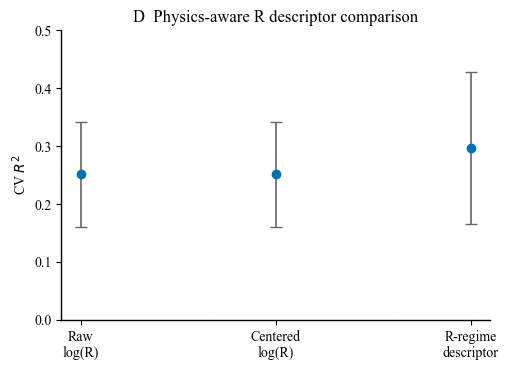

In [13]:
# Fig. 4D draft plot
fig, ax = plt.subplots(figsize=(5.2, 3.8))

x = np.arange(len(fig4D_df))

ax.errorbar(
    x,
    fig4D_df["cv_R2_mean"],
    yerr=fig4D_df["cv_R2_std"],
    fmt="o",
    markersize=6,
    capsize=4,
    color=COLORS["blue"],
    ecolor=COLORS["gray"],
    elinewidth=1.2
)

ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])

ax.set_xticks(x)
ax.set_xticklabels(fig4D_df["label"])
ax.set_ylabel("CV $R^2$")
ax.set_title("D  Physics-aware R descriptor comparison")
ax.set_ylim(0.0, 0.50)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Combined Figure 4

C:\Users\wenlu\AppData\Local\Temp\ipykernel_4456\3337030477.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


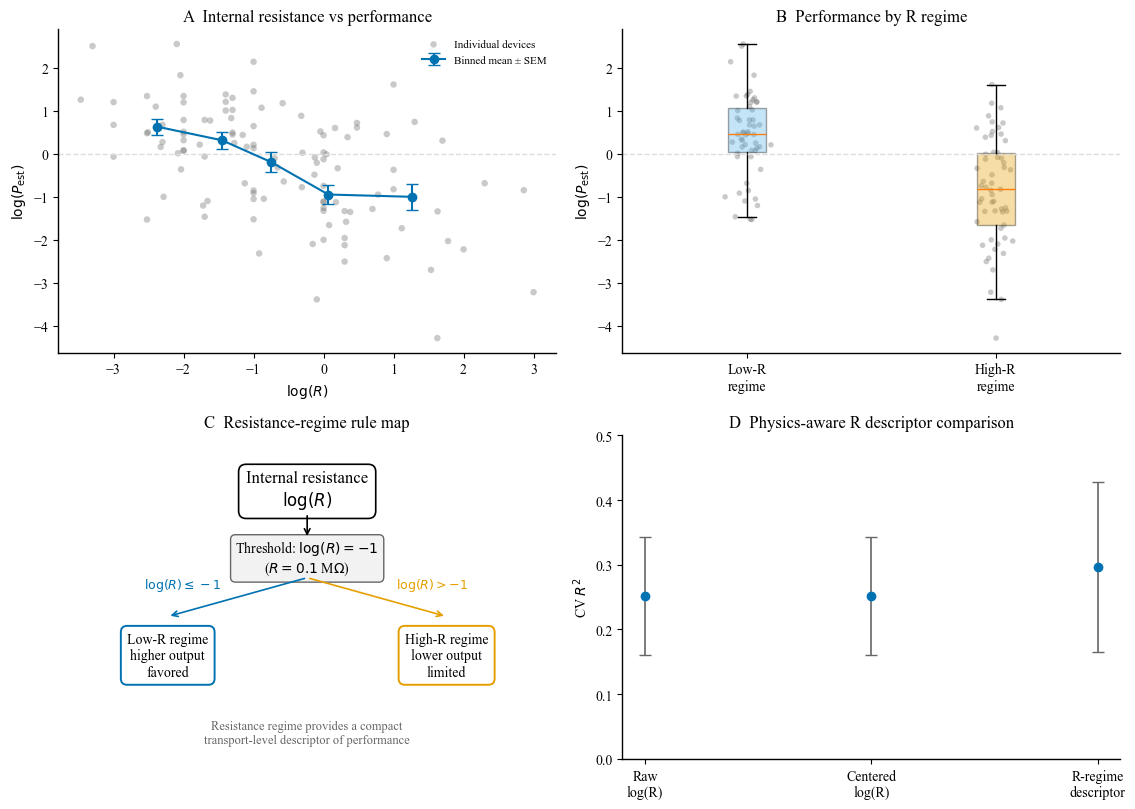

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.2))

# =========================
# A. log(R) vs log(P_est)
# =========================
ax = axes[0, 0]

ax.scatter(
    fig4A_df["log_R"],
    fig4A_df["log_P_est"],
    s=22,
    alpha=0.35,
    color=COLORS["gray"],
    edgecolor="none",
    label="Individual devices"
)

ax.errorbar(
    fig4A_bin_df["log_R_center"],
    fig4A_bin_df["mean_log_P_est"],
    yerr=fig4A_bin_df["sem_log_P_est"],
    fmt="o-",
    markersize=6,
    linewidth=1.5,
    capsize=4,
    color=COLORS["blue"],
    ecolor=COLORS["blue"],
    label="Binned mean ± SEM"
)

ax.set_xlabel(r"$\log(R)$")
ax.set_ylabel(r"$\log(P_\mathrm{est})$")
ax.set_title("A  Internal resistance vs performance")
ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])
ax.legend(frameon=False, fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# B. Performance by R regime
# =========================
ax = axes[0, 1]

box = ax.boxplot(
    data_by_regime,
    labels=["Low-R\nregime", "High-R\nregime"],
    patch_artist=True,
    showfliers=False
)

for patch, color in zip(box["boxes"], [COLORS["sky"], COLORS["orange"]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.35)

rng = np.random.default_rng(42)
for i, reg in enumerate(regime_order, start=1):
    y_vals = fig4B_df.loc[fig4B_df["R_regime"] == reg, "log_P_est"].values
    x_vals = rng.normal(loc=i, scale=0.045, size=len(y_vals))
    ax.scatter(
        x_vals,
        y_vals,
        s=16,
        alpha=0.35,
        color=COLORS["gray"],
        edgecolor="none"
    )

ax.set_ylabel(r"$\log(P_\mathrm{est})$")
ax.set_title("B  Performance by R regime")
ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# C. Rule schematic
# =========================
ax = axes[1, 0]
ax.axis("off")

x_center = 0.50
x_left = 0.22
x_right = 0.78

# Main node
ax.text(
    x_center,
    0.83,
    r"Internal resistance" + "\n" + r"$\log(R)$",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(
        boxstyle="round,pad=0.45",
        fc="white",
        ec=COLORS["black"],
        lw=1.2
    )
)

# Threshold node
ax.text(
    x_center,
    0.62,
    r"Threshold: $\log(R)=-1$" + "\n" + r"($R=0.1$ M$\Omega$)",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.35",
        fc=COLORS["very_light_gray"],
        ec=COLORS["gray"],
        lw=1.0
    )
)

# Low-R node
ax.text(
    x_left,
    0.32,
    "Low-R regime\nhigher output\nfavored",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.45",
        fc="white",
        ec=COLORS["blue"],
        lw=1.4
    )
)

# High-R node
ax.text(
    x_right,
    0.32,
    "High-R regime\nlower output\nlimited",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.45",
        fc="white",
        ec=COLORS["orange"],
        lw=1.4
    )
)

# Arrow: main node -> threshold
ax.annotate(
    "",
    xy=(x_center, 0.68),
    xytext=(x_center, 0.76),
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color=COLORS["black"]
    )
)

# Arrow: threshold -> low-R
ax.annotate(
    "",
    xy=(x_left, 0.44),
    xytext=(x_center, 0.56),
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color=COLORS["blue"]
    )
)

# Arrow: threshold -> high-R
ax.annotate(
    "",
    xy=(x_right, 0.44),
    xytext=(x_center, 0.56),
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color=COLORS["orange"]
    )
)

# Branch labels
ax.text(
    0.25,
    0.54,
    r"$\log(R)\leq -1$",
    ha="center",
    va="center",
    fontsize=9,
    color=COLORS["blue"]
)

ax.text(
    0.75,
    0.54,
    r"$\log(R)> -1$",
    ha="center",
    va="center",
    fontsize=9,
    color=COLORS["orange"]
)

# Bottom note
ax.text(
    x_center,
    0.08,
    "Resistance regime provides a compact\ntransport-level descriptor of performance",
    ha="center",
    va="center",
    fontsize=9,
    color=COLORS["gray"]
)

ax.set_title("C  Resistance-regime rule map")


# =========================
# D. Physics-aware R descriptor comparison
# =========================
ax = axes[1, 1]

x = np.arange(len(fig4D_df))

ax.errorbar(
    x,
    fig4D_df["cv_R2_mean"],
    yerr=fig4D_df["cv_R2_std"],
    fmt="o",
    markersize=6,
    capsize=4,
    color=COLORS["blue"],
    ecolor=COLORS["gray"],
    elinewidth=1.2
)

ax.axhline(0, linestyle="--", linewidth=1, color=COLORS["light_gray"])

ax.set_xticks(x)
ax.set_xticklabels(fig4D_df["label"])
ax.set_ylabel("CV $R^2$")
ax.set_title("D  Physics-aware R descriptor comparison")
ax.set_ylim(0.0, 0.50)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

fig.savefig(out_dir / "figure4_resistance_regimes_draft.png", dpi=300, bbox_inches="tight")
fig.savefig(out_dir / "figure4_resistance_regimes_draft.pdf", bbox_inches="tight")

plt.show()

## Export data for Igor Pro

In [15]:
fig4A_df.to_csv(
    out_dir / "fig4A_logR_vs_logPest_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

fig4A_bin_df.to_csv(
    out_dir / "fig4A_logR_vs_logPest_binned_trend.csv",
    index=False,
    encoding="utf-8-sig"
)

fig4B_df.to_csv(
    out_dir / "fig4B_R_regime_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

fig4B_summary_df.to_csv(
    out_dir / "fig4B_R_regime_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

fig4D_df.to_csv(
    out_dir / "fig4D_physics_aware_R_descriptor_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Exported files:")
for f in sorted(out_dir.glob("*")):
    print(f.name)

Exported files:
fig4A_logR_vs_logPest_binned_trend.csv
fig4A_logR_vs_logPest_raw.csv
fig4B_R_regime_raw.csv
fig4B_R_regime_summary.csv
fig4D_physics_aware_R_descriptor_comparison.csv
fig4D_R_descriptor_comparison.csv
figure4_resistance_regimes_draft.pdf
figure4_resistance_regimes_draft.png
final_panels


## Figure 4 summary

Figure 4 examines internal resistance as a regime-defining descriptor.

- Fig. 4A shows the direct relationship between log(R) and log(P_est).
- Fig. 4B compares performance distributions between low-R and high-R regimes.
- Fig. 4C summarizes the resistance-regime interpretation as a simple rule map.
- Fig. 4D compares raw log(R), centered log(R), and a physics-aware R-regime descriptor.

Together, these plots support the transition from "internal resistance is important" to "internal resistance organizes hydrovoltaic performance into resistance-controlled regimes."

In [16]:
fig4B_summary_df

,R_regime,count,mean_log_P_est,median_log_P_est,std_log_P_est,mean_log_R,median_log_R
0,low_R,55,0.413553,0.454845,0.957220,-1.807239,-1.721246
1,high_R,57,-0.850091,-0.823906,1.243873,0.425354,0.176091


In [17]:
fig4B_summary_df.to_csv(
    out_dir / "fig4B_R_regime_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

fig4D_df.to_csv(
    out_dir / "fig4D_R_descriptor_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

# Final Figure 4 production

This section generates the final single-panel plots for Figure 4.

Panels generated here:
- Fig. 4A: internal resistance vs performance
- Fig. 4B: performance by resistance regime
- Fig. 4D: physics-aware R descriptor comparison

Fig. 4C is prepared separately as a conceptual schematic and is not generated by Python.

The original analysis cells above are kept unchanged. The final plotting cells below read the exported CSV files generated by the earlier workflow.

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# Output folders
# =========================
fig4_dir = Path("../results/figure4_resistance_regimes")
final_dir = fig4_dir / "final_panels"
final_dir.mkdir(parents=True, exist_ok=True)

print("Figure 4 result folder:", fig4_dir.resolve())
print("Final panel output folder:", final_dir.resolve())


# =========================
# Figure style
# =========================
COLORS_FINAL = {
    "black": "#000000",
    "dark_gray": "#4D4D4D",
    "gray": "#8C8C8C",
    "light_gray": "#C7C7C7",
    "very_light_gray": "#EFEFEF",

    "vermillion": "#D55E00",
    "orange": "#E69F00",
    "green": "#009E73",
    "sky_blue": "#56B4E9",
    "blue": "#0072B2",
    "purple": "#CC79A7",
    "yellow": "#F0E442",
}

SEMANTIC_FINAL = {
    # Low-R / favorable
    "favorable": "#009E73",
    "favorable_fill": "#BFD8CF",

    # High-R / limited
    "limited": "#D55E00",
    "limited_fill": "#E7D3BE",

    # Neutral
    "raw_data": "#BDBDBD",
    "trend": "#000000",
    "reference": "#D0D0D0",
}


def set_final_style():
    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": 8.5,
        "font.weight": "normal",

        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",

        "axes.linewidth": 1.0,
        "axes.labelsize": 9.5,
        "axes.titlesize": 10,
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,

        "lines.linewidth": 1.2,
        "lines.markersize": 4,

        "legend.fontsize": 8,
        "legend.frameon": False,

        # Important for Illustrator editing
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        "savefig.dpi": 600,
        "figure.dpi": 150,
        "axes.grid": False,
    })


def format_final_ax(ax, mirror=True):
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color(COLORS_FINAL["black"])

    ax.spines["top"].set_visible(mirror)
    ax.spines["right"].set_visible(mirror)

    ax.tick_params(
        direction="out",
        width=1.0,
        length=4,
        color=COLORS_FINAL["black"],
        top=False,
        right=False,
    )

    return ax


def save_final_panel(fig, name):
    """
    Save one final panel for Illustrator assembly.
    """
    pdf_path = final_dir / f"{name}.pdf"
    svg_path = final_dir / f"{name}.svg"
    png_path = final_dir / f"{name}.png"

    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.03)
    fig.savefig(svg_path, bbox_inches="tight", pad_inches=0.03)
    fig.savefig(png_path, dpi=600, bbox_inches="tight", pad_inches=0.03)

    print("Saved:")
    print(" -", pdf_path.name)
    print(" -", svg_path.name)
    print(" -", png_path.name)


set_final_style()

Figure 4 result folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure4_resistance_regimes
Final panel output folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure4_resistance_regimes\final_panels


In [19]:
# =========================
# Load exported Figure 4 plotting data
# =========================

fig4A_raw_path = fig4_dir / "fig4A_logR_vs_logPest_raw.csv"
fig4A_bin_path = fig4_dir / "fig4A_logR_vs_logPest_binned_trend.csv"
fig4B_raw_path = fig4_dir / "fig4B_R_regime_raw.csv"
fig4B_summary_path = fig4_dir / "fig4B_R_regime_summary.csv"

# Prefer the final standardized Fig. 4D file name.
# Fallback to the earlier exported name if needed.
fig4D_path_candidates = [
    fig4_dir / "fig4D_R_descriptor_comparison.csv",
    fig4_dir / "fig4D_physics_aware_R_descriptor_comparison.csv",
]

fig4D_path = None
for p in fig4D_path_candidates:
    if p.exists():
        fig4D_path = p
        break

required_paths = [
    fig4A_raw_path,
    fig4A_bin_path,
    fig4B_raw_path,
    fig4B_summary_path,
]

for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

if fig4D_path is None:
    raise FileNotFoundError("Missing Fig. 4D descriptor comparison CSV.")

fig4A_raw = pd.read_csv(fig4A_raw_path, encoding="utf-8-sig")
fig4A_bin = pd.read_csv(fig4A_bin_path, encoding="utf-8-sig")
fig4B_raw = pd.read_csv(fig4B_raw_path, encoding="utf-8-sig")
fig4B_summary = pd.read_csv(fig4B_summary_path, encoding="utf-8-sig")
fig4D_df = pd.read_csv(fig4D_path, encoding="utf-8-sig")

print("Loaded:")
print(" -", fig4A_raw_path.name, fig4A_raw.shape)
print(" -", fig4A_bin_path.name, fig4A_bin.shape)
print(" -", fig4B_raw_path.name, fig4B_raw.shape)
print(" -", fig4B_summary_path.name, fig4B_summary.shape)
print(" -", fig4D_path.name, fig4D_df.shape)

display(fig4B_summary)
display(fig4D_df)

Loaded:
 - fig4A_logR_vs_logPest_raw.csv (112, 3)
 - fig4A_logR_vs_logPest_binned_trend.csv (5, 9)
 - fig4B_R_regime_raw.csv (112, 3)
 - fig4B_R_regime_summary.csv (2, 7)
 - fig4D_R_descriptor_comparison.csv (3, 5)


,R_regime,count,mean_log_P_est,median_log_P_est,std_log_P_est,mean_log_R,median_log_R
0,low_R,55,0.413553,0.454845,0.957220,-1.807239,-1.721246
1,high_R,57,-0.850091,-0.823906,1.243873,0.425354,0.176091


,descriptor_model,label,cv_R2_mean,cv_R2_std,test_R2
0,baseline_logR,Raw\nlog(R),0.251254,0.091204,0.428578
1,centered_logR,Centered\nlog(R),0.251254,0.091204,0.428578
2,R_regime_descriptor,R-regime\ndescriptor,0.296935,0.131584,0.518388


In [20]:
print("Fig. 4A raw n:", len(fig4A_raw))
print("Fig. 4B raw n:", len(fig4B_raw))
print()

print("R regime counts:")
print(fig4B_raw["R_regime"].value_counts())
print()

print("R regime summary:")
display(fig4B_summary)

# Expected:
# total n = 112
# low_R = 55
# high_R = 57
# low_R median log(P_est) ≈ 0.455
# high_R median log(P_est) ≈ -0.824

Fig. 4A raw n: 112
Fig. 4B raw n: 112

R regime counts:
R_regime
high_R    57
low_R     55
Name: count, dtype: int64

R regime summary:


,R_regime,count,mean_log_P_est,median_log_P_est,std_log_P_est,mean_log_R,median_log_R
0,low_R,55,0.413553,0.454845,0.957220,-1.807239,-1.721246
1,high_R,57,-0.850091,-0.823906,1.243873,0.425354,0.176091


Saved:
 - fig4A_final_internal_resistance_vs_performance.pdf
 - fig4A_final_internal_resistance_vs_performance.svg
 - fig4A_final_internal_resistance_vs_performance.png


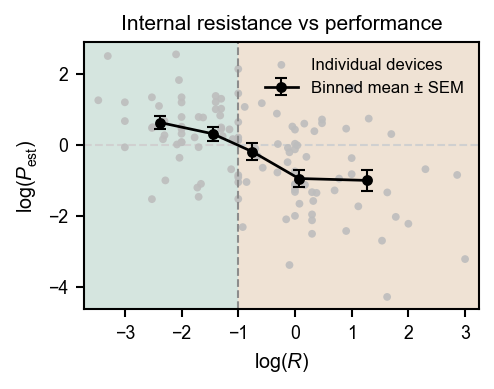

In [21]:
# =========================
# Final Fig. 4A
# Internal resistance vs performance
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(3.35, 2.65))

R_THRESHOLD = -1.0

# Axis range first, so shading covers the whole panel
x_pad = 0.25
xmin = fig4A_raw["log_R"].min() - x_pad
xmax = fig4A_raw["log_R"].max() + x_pad
ax.set_xlim(xmin, xmax)

# Low-R / high-R background shading
ax.axvspan(
    xmin,
    R_THRESHOLD,
    facecolor=SEMANTIC_FINAL["favorable_fill"],
    alpha=0.65,
    lw=0,
    zorder=0,
)

ax.axvspan(
    R_THRESHOLD,
    xmax,
    facecolor=SEMANTIC_FINAL["limited_fill"],
    alpha=0.65,
    lw=0,
    zorder=0,
)

# Raw data
ax.scatter(
    fig4A_raw["log_R"],
    fig4A_raw["log_P_est"],
    s=14,
    color=SEMANTIC_FINAL["raw_data"],
    alpha=0.9,
    edgecolor="none",
    label="Individual devices",
    zorder=1,
)

# Binned mean ± SEM
ax.errorbar(
    fig4A_bin["log_R_center"],
    fig4A_bin["mean_log_P_est"],
    yerr=fig4A_bin["sem_log_P_est"],
    fmt="o-",
    color=SEMANTIC_FINAL["trend"],
    ecolor=SEMANTIC_FINAL["trend"],
    elinewidth=1.0,
    capsize=3,
    markersize=4.2,
    markerfacecolor=SEMANTIC_FINAL["trend"],
    markeredgecolor=SEMANTIC_FINAL["trend"],
    linewidth=1.3,
    label="Binned mean ± SEM",
    zorder=3,
)

# Reference lines
ax.axhline(
    0,
    linestyle="--",
    linewidth=1.0,
    color=SEMANTIC_FINAL["reference"],
    zorder=0,
)

ax.axvline(
    R_THRESHOLD,
    linestyle="--",
    linewidth=1.0,
    color=COLORS_FINAL["gray"],
    zorder=1,
)

ax.set_xlabel(r"$\log(R)$")
ax.set_ylabel(r"$\log(P_{\mathrm{est}})$")
ax.set_title("Internal resistance vs performance")

format_final_ax(ax, mirror=True)
ax.legend(loc="upper right", frameon=False)

plt.tight_layout()

save_final_panel(fig, "fig4A_final_internal_resistance_vs_performance")

plt.show()

Saved:
 - fig4B_final_performance_by_R_regime.pdf
 - fig4B_final_performance_by_R_regime.svg
 - fig4B_final_performance_by_R_regime.png


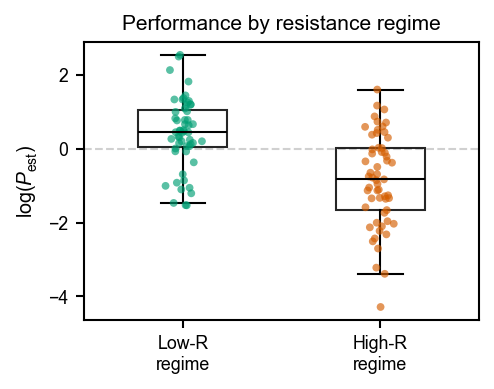

In [22]:
# =========================
# Final Fig. 4B
# Performance by resistance regime
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(3.35, 2.65))

regime_order = ["low_R", "high_R"]
regime_labels = ["Low-R\nregime", "High-R\nregime"]
positions = np.arange(1, len(regime_order) + 1)

data_by_regime = [
    fig4B_raw.loc[
        fig4B_raw["R_regime"] == reg,
        "log_P_est"
    ].dropna().values
    for reg in regime_order
]

box_fill_colors = [
    SEMANTIC_FINAL["favorable_fill"],
    SEMANTIC_FINAL["limited_fill"],
]

point_colors = [
    SEMANTIC_FINAL["favorable"],
    SEMANTIC_FINAL["limited"],
]

box = ax.boxplot(
    data_by_regime,
    positions=positions,
    widths=0.45,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(
        color=COLORS_FINAL["black"],
        linewidth=1.0,
    ),
    boxprops=dict(
        linewidth=1.0,
        color=COLORS_FINAL["black"],
    ),
    whiskerprops=dict(
        linewidth=1.0,
        color=COLORS_FINAL["black"],
    ),
    capprops=dict(
        linewidth=1.0,
        color=COLORS_FINAL["black"],
    ),
)

for patch, color in zip(box["boxes"], box_fill_colors):
    patch.set_facecolor("none")
    patch.set_alpha(0.85)
    patch.set_edgecolor(COLORS_FINAL["black"])

# Jittered raw points
rng = np.random.default_rng(42)

for i, reg in enumerate(regime_order, start=1):
    y = fig4B_raw.loc[
        fig4B_raw["R_regime"] == reg,
        "log_P_est"
    ].dropna().values

    x = rng.normal(
        loc=i,
        scale=0.045,
        size=len(y),
    )

    ax.scatter(
        x,
        y,
        s=14,
        color=point_colors[i - 1],
        alpha=0.65,
        edgecolor="none",
        zorder=2,
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.0,
    color=SEMANTIC_FINAL["reference"],
    zorder=0,
)

ax.set_xticks(positions)
ax.set_xticklabels(regime_labels)

ax.set_ylabel(r"$\log(P_{\mathrm{est}})$")
ax.set_title("Performance by resistance regime")

format_final_ax(ax, mirror=True)

plt.tight_layout()

save_final_panel(fig, "fig4B_final_performance_by_R_regime")

plt.show()

In [23]:
# =========================
# Prepare Fig. 4D plotting table
# =========================

fig4D_plot = fig4D_df.copy()

print("Fig. 4D columns:")
print(fig4D_plot.columns.tolist())

# Most recent file uses:
# descriptor_model, label, cv_R2_mean, cv_R2_std, test_R2
if "label" in fig4D_plot.columns:
    label_col = "label"
elif "descriptor_model" in fig4D_plot.columns:
    label_col = "descriptor_model"
elif "descriptor" in fig4D_plot.columns:
    label_col = "descriptor"
else:
    raise ValueError("Cannot find descriptor label column for Fig. 4D.")

if "cv_R2_mean" not in fig4D_plot.columns:
    raise ValueError("Cannot find cv_R2_mean column for Fig. 4D.")

if "cv_R2_std" not in fig4D_plot.columns:
    raise ValueError("Cannot find cv_R2_std column for Fig. 4D.")

fig4D_plot["plot_label"] = fig4D_plot[label_col].astype(str)

# Make labels more compact for the final plot
fig4D_plot["plot_label"] = (
    fig4D_plot["plot_label"]
    .str.replace("Raw log(R)", "Raw\nlog(R)", regex=False)
    .str.replace("Centered log(R)", "Centered\nlog(R)", regex=False)
    .str.replace("R-regime descriptor", "R-regime\ndescriptor", regex=False)
    .str.replace("R_regime_descriptor", "R-regime\ndescriptor", regex=False)
    .str.replace("raw_logR", "Raw\nlog(R)", regex=False)
    .str.replace("centered_logR", "Centered\nlog(R)", regex=False)
)

display(fig4D_plot[[label_col, "plot_label", "cv_R2_mean", "cv_R2_std"]])

Fig. 4D columns:
['descriptor_model', 'label', 'cv_R2_mean', 'cv_R2_std', 'test_R2']


,label,plot_label,cv_R2_mean,cv_R2_std
0,Raw\nlog(R),Raw\nlog(R),0.251254,0.091204
1,Centered\nlog(R),Centered\nlog(R),0.251254,0.091204
2,R-regime\ndescriptor,R-regime\ndescriptor,0.296935,0.131584


Saved:
 - fig4D_final_R_descriptor_comparison.pdf
 - fig4D_final_R_descriptor_comparison.svg
 - fig4D_final_R_descriptor_comparison.png


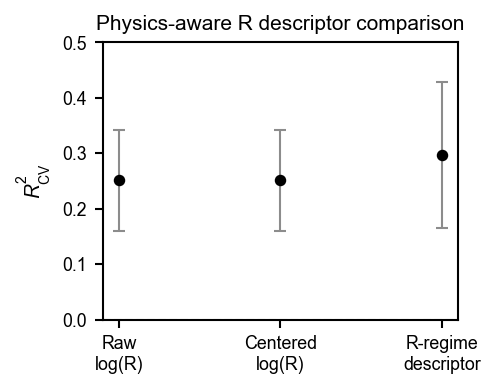

In [24]:
# =========================
# Final Fig. 4D
# Physics-aware R descriptor comparison
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(3.35, 2.65))

x = np.arange(len(fig4D_plot))
y = fig4D_plot["cv_R2_mean"].astype(float).values
yerr = fig4D_plot["cv_R2_std"].astype(float).values

ax.errorbar(
    x,
    y,
    yerr=yerr,
    fmt="o",
    color=COLORS_FINAL["black"],
    ecolor=COLORS_FINAL["gray"],
    elinewidth=1.0,
    capsize=3,
    markersize=4.5,
    markerfacecolor=COLORS_FINAL["black"],
    markeredgecolor=COLORS_FINAL["black"],
    zorder=3,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.0,
    color=SEMANTIC_FINAL["reference"],
    zorder=0,
)

ax.set_xticks(x)
ax.set_xticklabels(fig4D_plot["plot_label"])

ax.set_ylabel(r"$R^2_{\mathrm{CV}}$")
ax.set_ylim(0, 0.50)

ax.set_title("Physics-aware R descriptor comparison")

format_final_ax(ax, mirror=True)

plt.tight_layout()

save_final_panel(fig, "fig4D_final_R_descriptor_comparison")

plt.show()

In [25]:
print("Final Figure 4 panel files:")

for p in sorted(final_dir.glob("fig4*_final*")):
    print(" -", p.name)

Final Figure 4 panel files:
 - fig4A_final_internal_resistance_vs_performance.pdf
 - fig4A_final_internal_resistance_vs_performance.png
 - fig4A_final_internal_resistance_vs_performance.svg
 - fig4B_final_performance_by_R_regime.pdf
 - fig4B_final_performance_by_R_regime.png
 - fig4B_final_performance_by_R_regime.svg
 - fig4D_final_R_descriptor_comparison.pdf
 - fig4D_final_R_descriptor_comparison.png
 - fig4D_final_R_descriptor_comparison.svg
